## Load Data

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

_notebook_dir = Path.cwd()
if _notebook_dir.name == "notebooks":
    dataset_path = _notebook_dir.parent / "dataset" / "pokemon_cards_dataset_cleaned.csv"
else:
    dataset_path = _notebook_dir / "backend" / "dataset" / "pokemon_cards_dataset_cleaned.csv"

try:
    df = pd.read_csv(dataset_path)
    df.info()
    print("\nData berhasil dimuat!")
except FileNotFoundError:
    print(f"File tidak ditemukan di: {dataset_path}")

<class 'pandas.DataFrame'>
RangeIndex: 20426 entries, 0 to 20425
Data columns (total 22 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   card_id                                           20426 non-null  str    
 1   name                                              20426 non-null  str    
 2   supertype                                         20426 non-null  str    
 3   subtypes                                          20252 non-null  str    
 4   types                                             17240 non-null  str    
 5   hp                                                17273 non-null  float64
 6   number                                            20426 non-null  str    
 7   rarity                                            20170 non-null  str    
 8   artist                                            19149 non-null  str    
 9   set.id                      

## Definisikan Target Harga

In [12]:
# Kandidat target variable
df[["prices.tcgplayer_variants.normal.market", "prices.cardmarket_avg_sell", "effective_market_price"]].describe()

,prices.tcgplayer_variants.normal.market,prices.cardmarket_avg_sell,effective_market_price
count,11540.000000,19081.000000,19686.000000
mean,4.795507,12.835737,22.389274
std,42.140914,141.372677,115.380706
min,0.010000,0.000000,0.010000
25%,0.170000,0.120000,0.250000
50%,0.320000,0.670000,0.960000
75%,1.080000,4.390000,7.427500
max,2500.990000,14999.990000,4500.000000


## Heatmap Korelasi

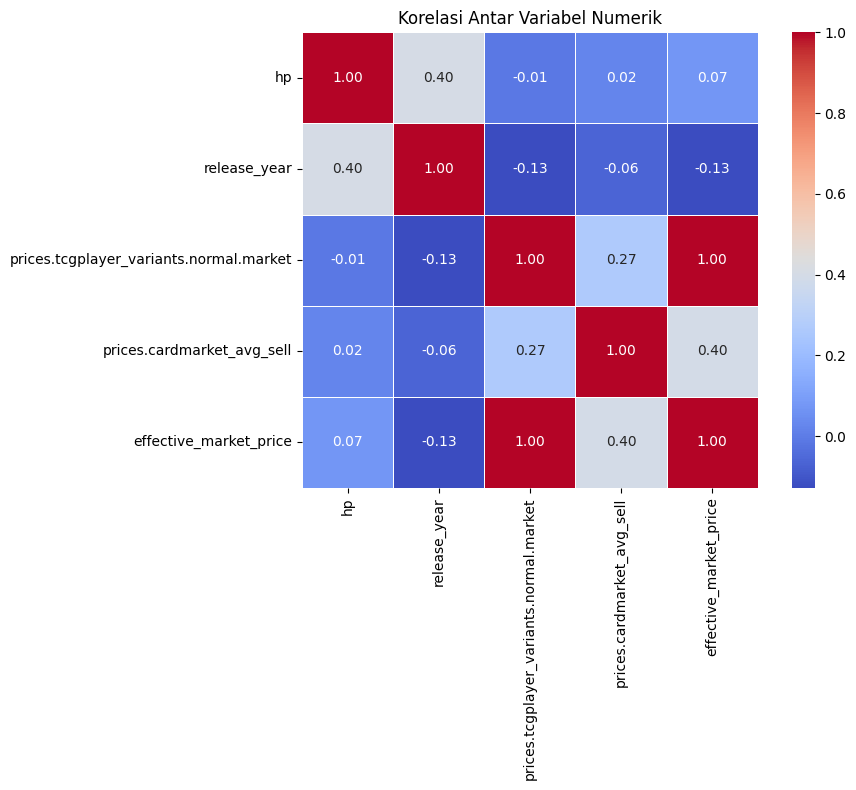

In [14]:
# Pilih variabel numerik yang relevan dengan nama asli dari CSV
numerik = [
    "hp", 
    "release_year", 
    "prices.tcgplayer_variants.normal.market", 
    "prices.cardmarket_avg_sell", 
    "effective_market_price"
]

corr = df[numerik].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", 
            square=True, linewidths=0.5)
plt.title("Korelasi Antar Variabel Numerik")
plt.tight_layout()
plt.show()

## Analisis Artist vs Harga

In [17]:
# Top 20 artist berdasarkan rata-rata harga
artist_price = (
    df.groupby("artist")
    .agg(
        mean_price=("effective_market_price", "mean"),
        card_count=("effective_market_price", "count"),
    )
    .query("card_count >= 5")
    .sort_values("mean_price", ascending=False)
    .head(20)
)

print(artist_price)

                              mean_price  card_count
artist                                              
Shinji Higuchi + Sachiko Eba  282.523000          10
Kimiya Masago                 268.221200          25
Pokemon Rumble                255.156250          16
Hikaru Koike                  221.996596          47
"Big Mama" Tagawa             151.213529          17
The Pokémon Company Art Team  143.025000          16
Hironobu Yoshida              100.971579          38
Masakazu Fukuda                95.625681         470
Keiko Fukuyama                 92.990500          20
K. Hoshiba                     92.402857           7
Shizurow                       79.388500          80
Shin-ichi Yoshida              77.269423          52
Ryo Ueda                       75.579437         462
Hideaki Hakozaki               75.194167          36
Yuri Umemura                   74.476667           6
Noriko Hotta                   66.763333          21
Shinji Kanda                   66.687273      

## Rarity x Type x Harga

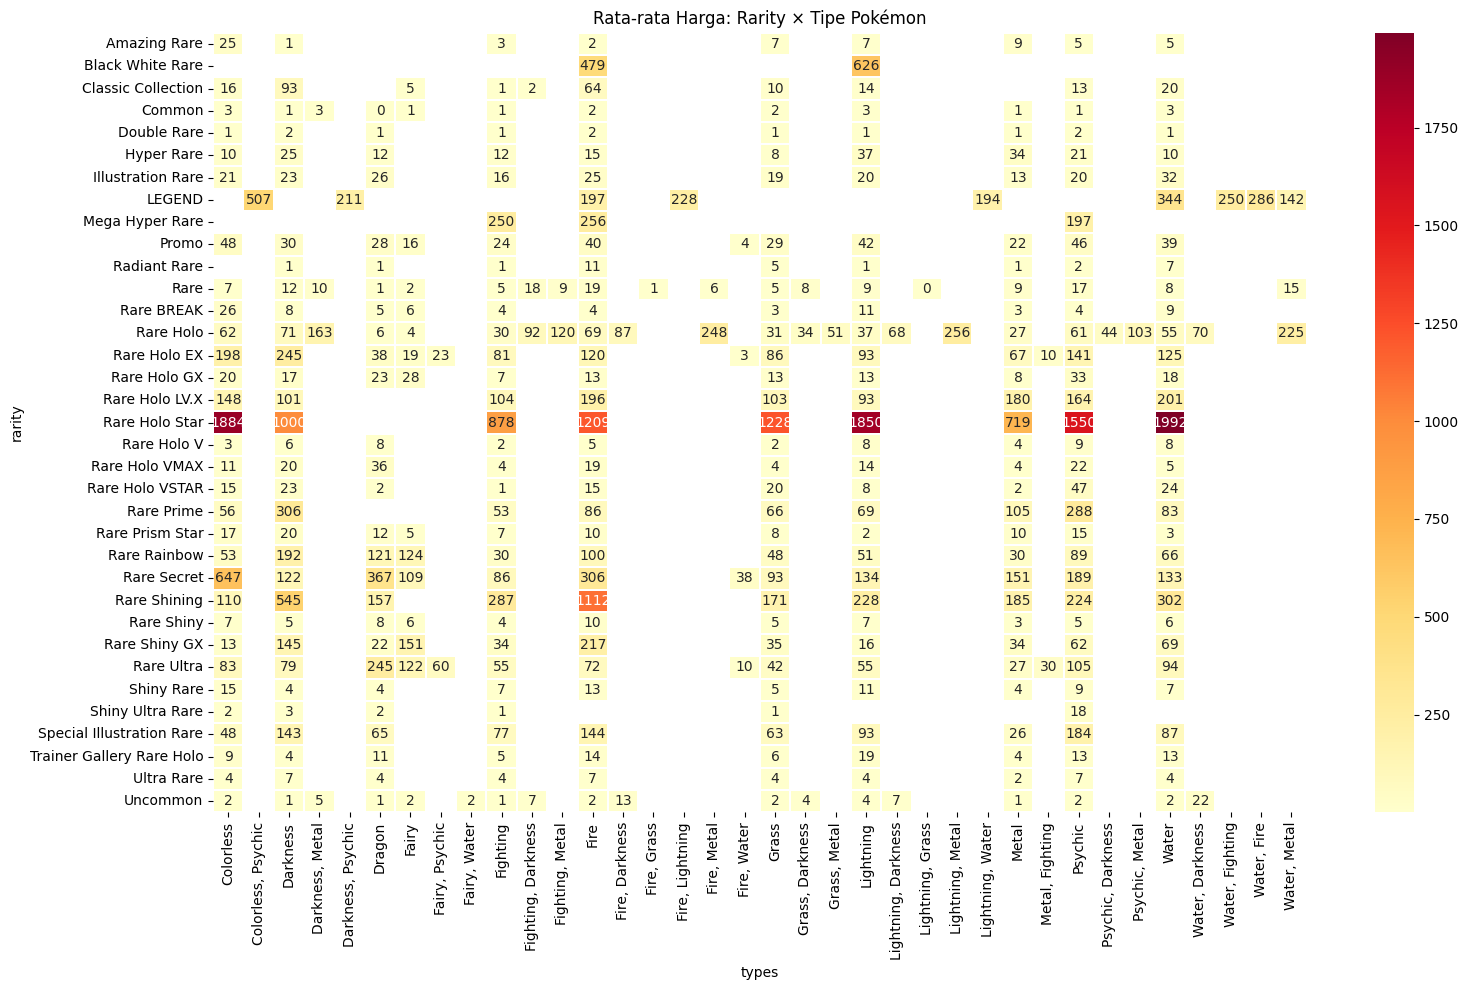

In [16]:
# Pivot table: Rarity vs Type → rata-rata harga
pivot = df.pivot_table(
    values="effective_market_price",
    index="rarity",
    columns="types",    # atau supertype
    aggfunc="mean"
)

plt.figure(figsize=(16, 10))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.3)
plt.title("Rata-rata Harga: Rarity × Tipe Pokémon")
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

analysis_df = df.copy()

# Pastikan kolom harga berbentuk numerik
analysis_df["effective_market_price"] = pd.to_numeric(
    analysis_df["effective_market_price"],
    errors="coerce",
)

analysis_df["release_year"] = pd.to_numeric(
    analysis_df["release_year"],
    errors="coerce",
)

# Hanya kartu yang memiliki harga dan tahun rilis
analysis_df = analysis_df.dropna(
    subset=[
        "effective_market_price",
        "release_year",
    ]
).copy()

# Harga tidak boleh nol atau negatif untuk analisis harga
analysis_df = analysis_df[
    analysis_df["effective_market_price"] > 0
].copy()

print(f"Jumlah kartu untuk analisis: {len(analysis_df):,}")

Jumlah kartu untuk analisis: 19,686


## Kelompokkan Kartu Berdasarkan Era

In [25]:
def classify_era(year):
    if year <= 2003:
        return "Vintage\n(≤ 2003)"
    elif year <= 2010:
        return "Diamond & Pearl\n(2004–2010)"
    elif year <= 2013:
        return "Black & White\n(2011–2013)"
    elif year <= 2016:
        return "XY\n(2014–2016)"
    elif year <= 2019:
        return "Sun & Moon\n(2017–2019)"
    elif year <= 2022:
        return "Sword & Shield\n(2020–2022)"
    else:
        return "Scarlet & Violet\n(2023+)"

analysis_df["era"] = analysis_df["release_year"].apply(classify_era)

era_order = [
    "Vintage\n(≤ 2003)",
    "Diamond & Pearl\n(2004–2010)",
    "Black & White\n(2011–2013)",
    "XY\n(2014–2016)",
    "Sun & Moon\n(2017–2019)",
    "Sword & Shield\n(2020–2022)",
    "Scarlet & Violet\n(2023+)",
]

analysis_df["era"] = pd.Categorical(
    analysis_df["era"],
    categories=era_order,
    ordered=True,
)

## Heatmap: Rarity x Era

In [28]:
MIN_SAMPLE = 20
MAX_RARITY = 16

rarity_stats = (
    analysis_df
    .dropna(subset=["rarity"])
    .groupby("rarity")
    .agg(
        card_count=("effective_market_price", "count"),
        median_price=("effective_market_price", "median"),
    )
)

rarity_stats = rarity_stats[
    rarity_stats["card_count"] >= MIN_SAMPLE
]

common_rarities = (
    rarity_stats
    .sort_values("card_count", ascending=False)
    .head(12)
    .index
    .tolist()
)

expensive_rarities = (
    rarity_stats
    .sort_values("median_price", ascending=False)
    .head(8)
    .index
    .tolist()
)

selected_rarities = list(
    dict.fromkeys(common_rarities + expensive_rarities)
)[:MAX_RARITY]

# Urutan dari median harga tertinggi ke terendah
selected_rarities = (
    rarity_stats
    .loc[selected_rarities]
    .sort_values("median_price", ascending=False)
    .index
    .tolist()
)

print("Rarity yang ditampilkan:")
for rarity in selected_rarities:
    print(f"- {rarity}")

Rarity yang ditampilkan:
- Rare Holo Star
- Rare Holo LV.X
- Rare Prime
- Rare Holo EX
- Special Illustration Rare
- Rare Ultra
- Rare Rainbow
- Rare Secret
- Illustration Rare
- Promo
- Rare Holo
- Ultra Rare
- Rare Holo V
- Rare
- Uncommon
- Common


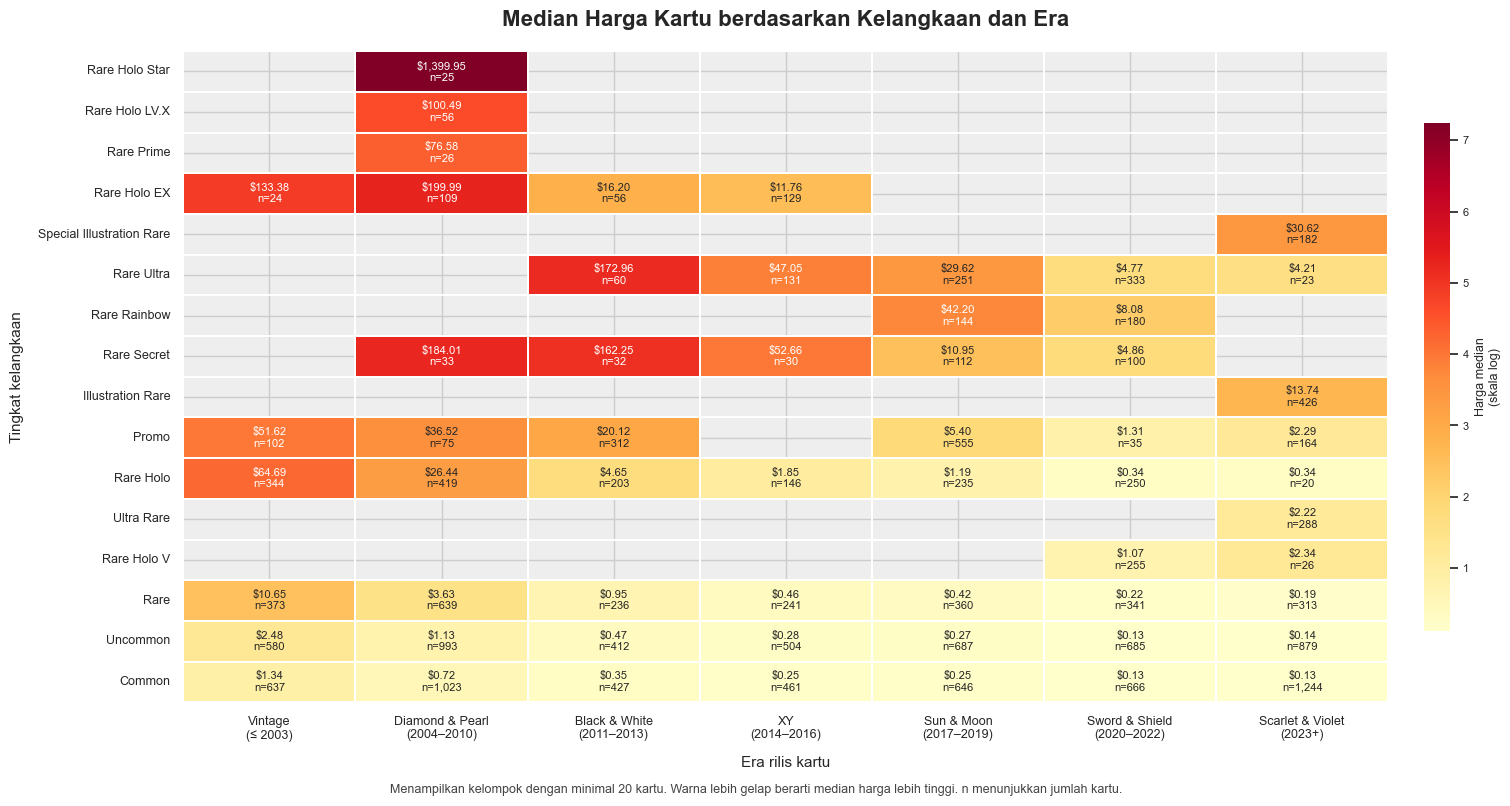

In [29]:
rarity_era_summary = (
    analysis_df
    .dropna(subset=["rarity", "era"])
    .groupby(
        ["rarity", "era"],
        observed=False,
    )
    .agg(
        median_price=("effective_market_price", "median"),
        card_count=("effective_market_price", "count"),
    )
    .reset_index()
)

rarity_era_summary = rarity_era_summary[
    rarity_era_summary["rarity"].isin(selected_rarities)
].copy()

# Jangan tampilkan kombinasi dengan sampel terlalu sedikit
rarity_era_summary.loc[
    rarity_era_summary["card_count"] < MIN_SAMPLE,
    "median_price",
] = np.nan

price_matrix = (
    rarity_era_summary
    .pivot(
        index="rarity",
        columns="era",
        values="median_price",
    )
    .reindex(
        index=selected_rarities,
        columns=era_order,
    )
)

count_matrix = (
    rarity_era_summary
    .pivot(
        index="rarity",
        columns="era",
        values="card_count",
    )
    .reindex(
        index=selected_rarities,
        columns=era_order,
    )
)

# Log dipakai hanya untuk pewarnaan, bukan untuk angka anotasi
color_matrix = np.log1p(price_matrix)

# Anotasi ringkas
annotation_matrix = price_matrix.copy().astype(object)

for row in price_matrix.index:
    for column in price_matrix.columns:
        price = price_matrix.loc[row, column]
        count = count_matrix.loc[row, column]

        if pd.isna(price) or pd.isna(count):
            annotation_matrix.loc[row, column] = ""
        else:
            annotation_matrix.loc[row, column] = (
                f"${price:,.2f}\n"
                f"n={int(count):,}"
            )

# Mask sel kosong
mask = price_matrix.isna()

# Ukuran figure berdasarkan jumlah rarity
fig_height = max(7, len(price_matrix) * 0.48)

fig, ax = plt.subplots(
    figsize=(15, fig_height),
    constrained_layout=True,
)

heatmap = sns.heatmap(
    color_matrix,
    mask=mask,
    annot=annotation_matrix,
    fmt="",
    cmap="YlOrRd",
    linewidths=1.2,
    linecolor="white",
    annot_kws={
        "fontsize": 8,
        "ha": "center",
        "va": "center",
    },
    cbar_kws={
        "label": "Intensitas harga median\n(skala logaritmik)",
        "shrink": 0.78,
        "pad": 0.03,
    },
    ax=ax,
)

# Sel kosong diberi warna abu-abu
ax.set_facecolor("#eeeeee")

ax.set_title(
    "Median Harga Kartu berdasarkan Kelangkaan dan Era",
    fontsize=16,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Era rilis kartu",
    fontsize=11,
    labelpad=10,
)

ax.set_ylabel(
    "Tingkat kelangkaan",
    fontsize=11,
    labelpad=10,
)

ax.tick_params(
    axis="x",
    labelrotation=0,
    labelsize=9,
)

ax.tick_params(
    axis="y",
    labelrotation=0,
    labelsize=9,
)

# Judul colorbar dibuat lebih singkat
colorbar = heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=8)
colorbar.set_label(
    "Harga median\n(skala log)",
    fontsize=9,
)

fig.text(
    0.5,
    -0.025,
    (
        f"Menampilkan kelompok dengan minimal {MIN_SAMPLE} kartu. "
        "Warna lebih gelap berarti median harga lebih tinggi. "
        "n menunjukkan jumlah kartu."
    ),
    ha="center",
    fontsize=9,
    color="#444444",
)

plt.show()

## Rarity x Era

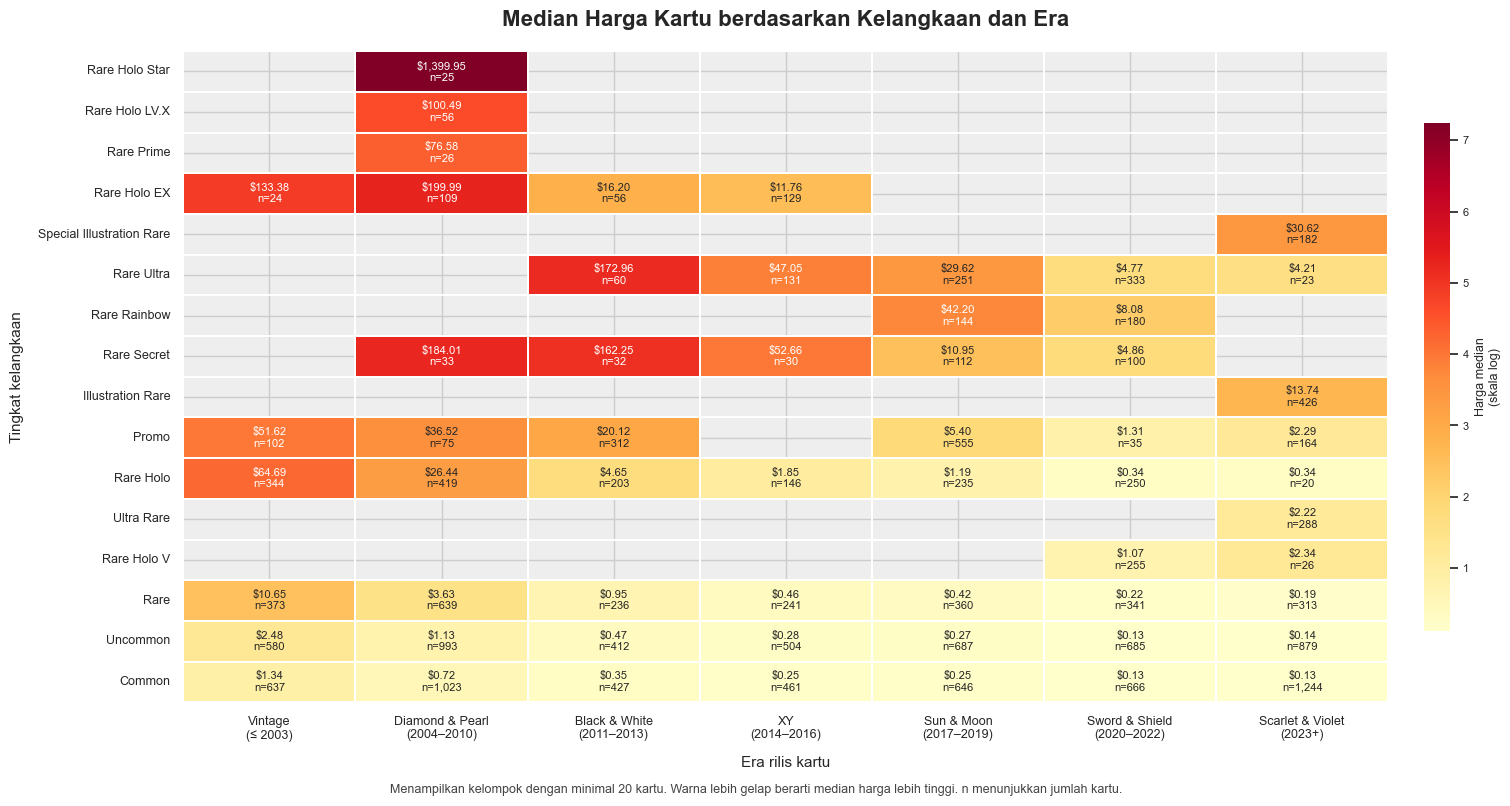

In [30]:
rarity_era_summary = (
    analysis_df
    .dropna(subset=["rarity", "era"])
    .groupby(
        ["rarity", "era"],
        observed=False,
    )
    .agg(
        median_price=("effective_market_price", "median"),
        card_count=("effective_market_price", "count"),
    )
    .reset_index()
)

rarity_era_summary = rarity_era_summary[
    rarity_era_summary["rarity"].isin(selected_rarities)
].copy()

# Jangan tampilkan kombinasi dengan sampel terlalu sedikit
rarity_era_summary.loc[
    rarity_era_summary["card_count"] < MIN_SAMPLE,
    "median_price",
] = np.nan

price_matrix = (
    rarity_era_summary
    .pivot(
        index="rarity",
        columns="era",
        values="median_price",
    )
    .reindex(
        index=selected_rarities,
        columns=era_order,
    )
)

count_matrix = (
    rarity_era_summary
    .pivot(
        index="rarity",
        columns="era",
        values="card_count",
    )
    .reindex(
        index=selected_rarities,
        columns=era_order,
    )
)

# Log dipakai hanya untuk pewarnaan, bukan untuk angka anotasi
color_matrix = np.log1p(price_matrix)

# Anotasi ringkas
annotation_matrix = price_matrix.copy().astype(object)

for row in price_matrix.index:
    for column in price_matrix.columns:
        price = price_matrix.loc[row, column]
        count = count_matrix.loc[row, column]

        if pd.isna(price) or pd.isna(count):
            annotation_matrix.loc[row, column] = ""
        else:
            annotation_matrix.loc[row, column] = (
                f"${price:,.2f}\n"
                f"n={int(count):,}"
            )

# Mask sel kosong
mask = price_matrix.isna()

# Ukuran figure berdasarkan jumlah rarity
fig_height = max(7, len(price_matrix) * 0.48)

fig, ax = plt.subplots(
    figsize=(15, fig_height),
    constrained_layout=True,
)

heatmap = sns.heatmap(
    color_matrix,
    mask=mask,
    annot=annotation_matrix,
    fmt="",
    cmap="YlOrRd",
    linewidths=1.2,
    linecolor="white",
    annot_kws={
        "fontsize": 8,
        "ha": "center",
        "va": "center",
    },
    cbar_kws={
        "label": "Intensitas harga median\n(skala logaritmik)",
        "shrink": 0.78,
        "pad": 0.03,
    },
    ax=ax,
)

# Sel kosong diberi warna abu-abu
ax.set_facecolor("#eeeeee")

ax.set_title(
    "Median Harga Kartu berdasarkan Kelangkaan dan Era",
    fontsize=16,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Era rilis kartu",
    fontsize=11,
    labelpad=10,
)

ax.set_ylabel(
    "Tingkat kelangkaan",
    fontsize=11,
    labelpad=10,
)

ax.tick_params(
    axis="x",
    labelrotation=0,
    labelsize=9,
)

ax.tick_params(
    axis="y",
    labelrotation=0,
    labelsize=9,
)

# Judul colorbar dibuat lebih singkat
colorbar = heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=8)
colorbar.set_label(
    "Harga median\n(skala log)",
    fontsize=9,
)

fig.text(
    0.5,
    -0.025,
    (
        f"Menampilkan kelompok dengan minimal {MIN_SAMPLE} kartu. "
        "Warna lebih gelap berarti median harga lebih tinggi. "
        "n menunjukkan jumlah kartu."
    ),
    ha="center",
    fontsize=9,
    color="#444444",
)

plt.show()

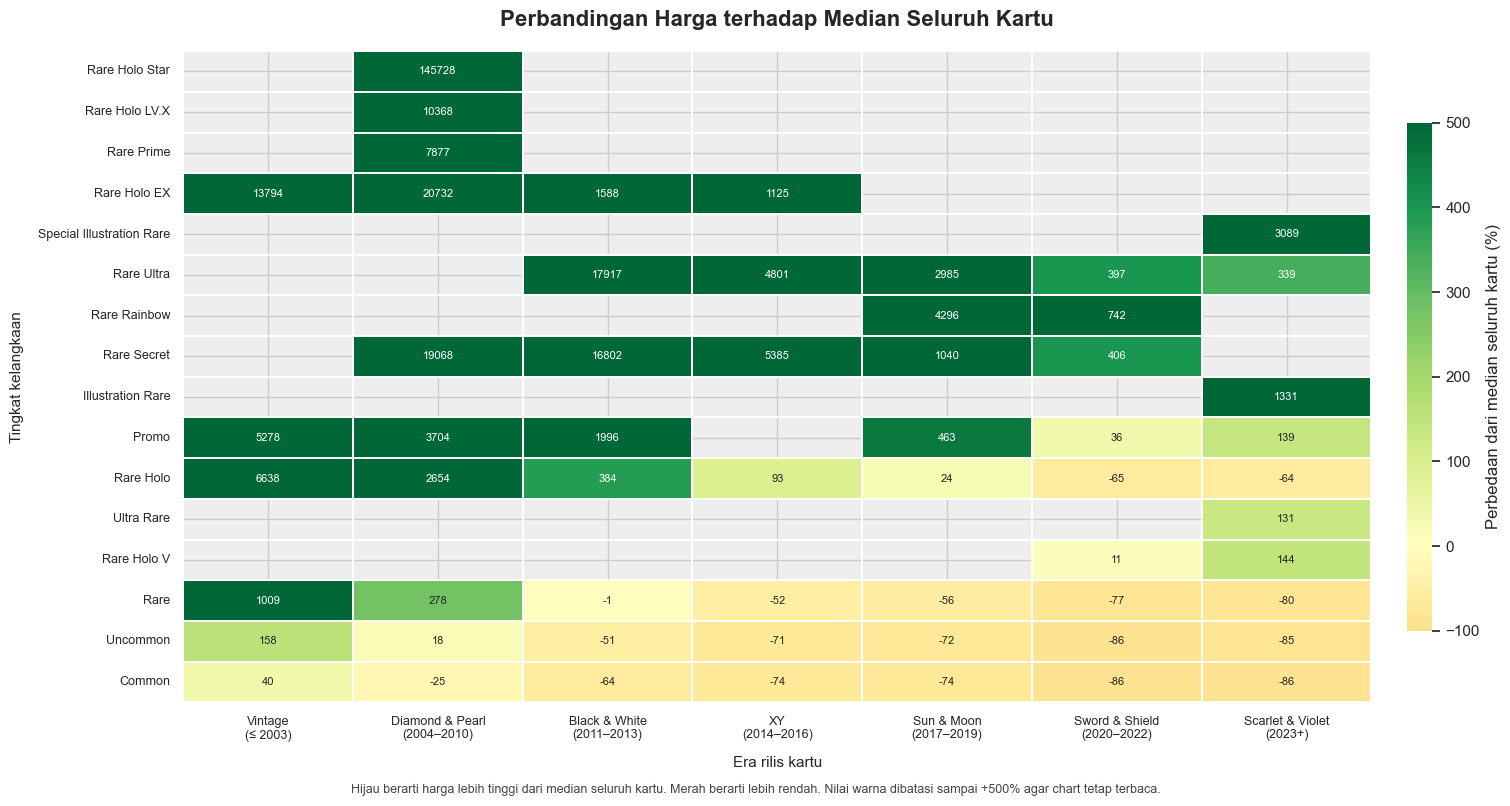

In [31]:
overall_median = analysis_df["effective_market_price"].median()

relative_matrix = (
    (price_matrix / overall_median) - 1
) * 100

# Batasi warna agar outlier tidak merusak keseluruhan visual
relative_for_color = relative_matrix.clip(
    lower=-100,
    upper=500,
)

fig, ax = plt.subplots(
    figsize=(15, fig_height),
    constrained_layout=True,
)

sns.heatmap(
    relative_for_color,
    mask=relative_matrix.isna(),
    annot=relative_matrix.round(0),
    fmt=".0f",
    cmap="RdYlGn",
    center=0,
    vmin=-100,
    vmax=500,
    linewidths=1.2,
    linecolor="white",
    annot_kws={
        "fontsize": 8,
        "ha": "center",
        "va": "center",
    },
    cbar_kws={
        "label": "Perbedaan dari median seluruh kartu (%)",
        "shrink": 0.78,
        "pad": 0.03,
    },
    ax=ax,
)

ax.set_facecolor("#eeeeee")

ax.set_title(
    "Perbandingan Harga terhadap Median Seluruh Kartu",
    fontsize=16,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Era rilis kartu",
    fontsize=11,
    labelpad=10,
)

ax.set_ylabel(
    "Tingkat kelangkaan",
    fontsize=11,
    labelpad=10,
)

ax.tick_params(
    axis="x",
    labelrotation=0,
    labelsize=9,
)

ax.tick_params(
    axis="y",
    labelrotation=0,
    labelsize=9,
)

fig.text(
    0.5,
    -0.025,
    (
        "Hijau berarti harga lebih tinggi dari median seluruh kartu. "
        "Merah berarti lebih rendah. "
        "Nilai warna dibatasi sampai +500% agar chart tetap terbaca."
    ),
    ha="center",
    fontsize=9,
    color="#444444",
)

plt.show()

## Tipe Pokemon x Rarity

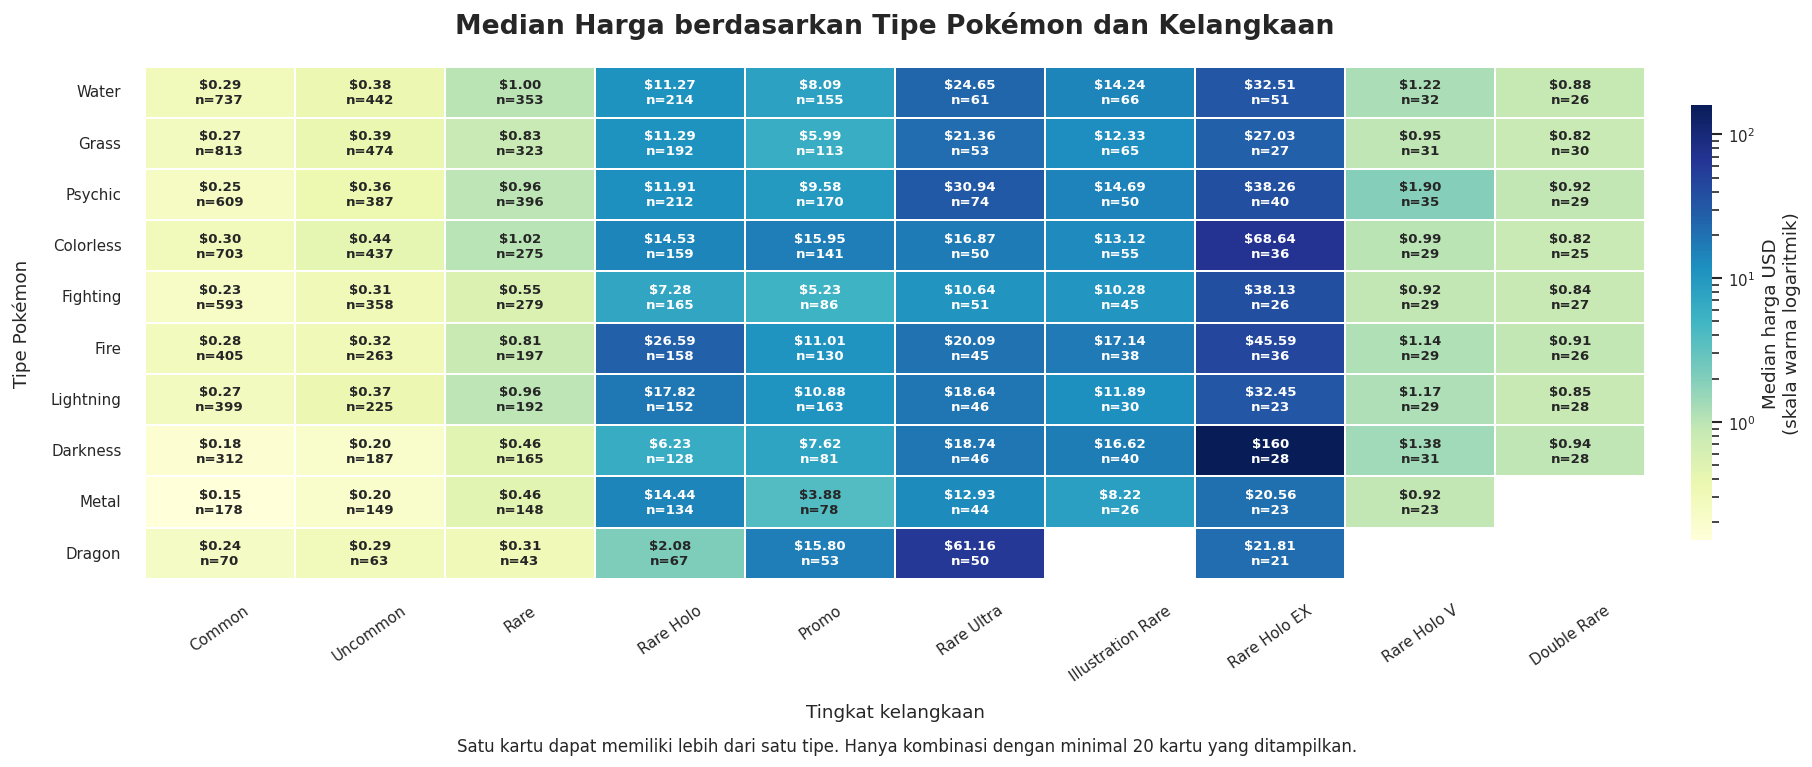

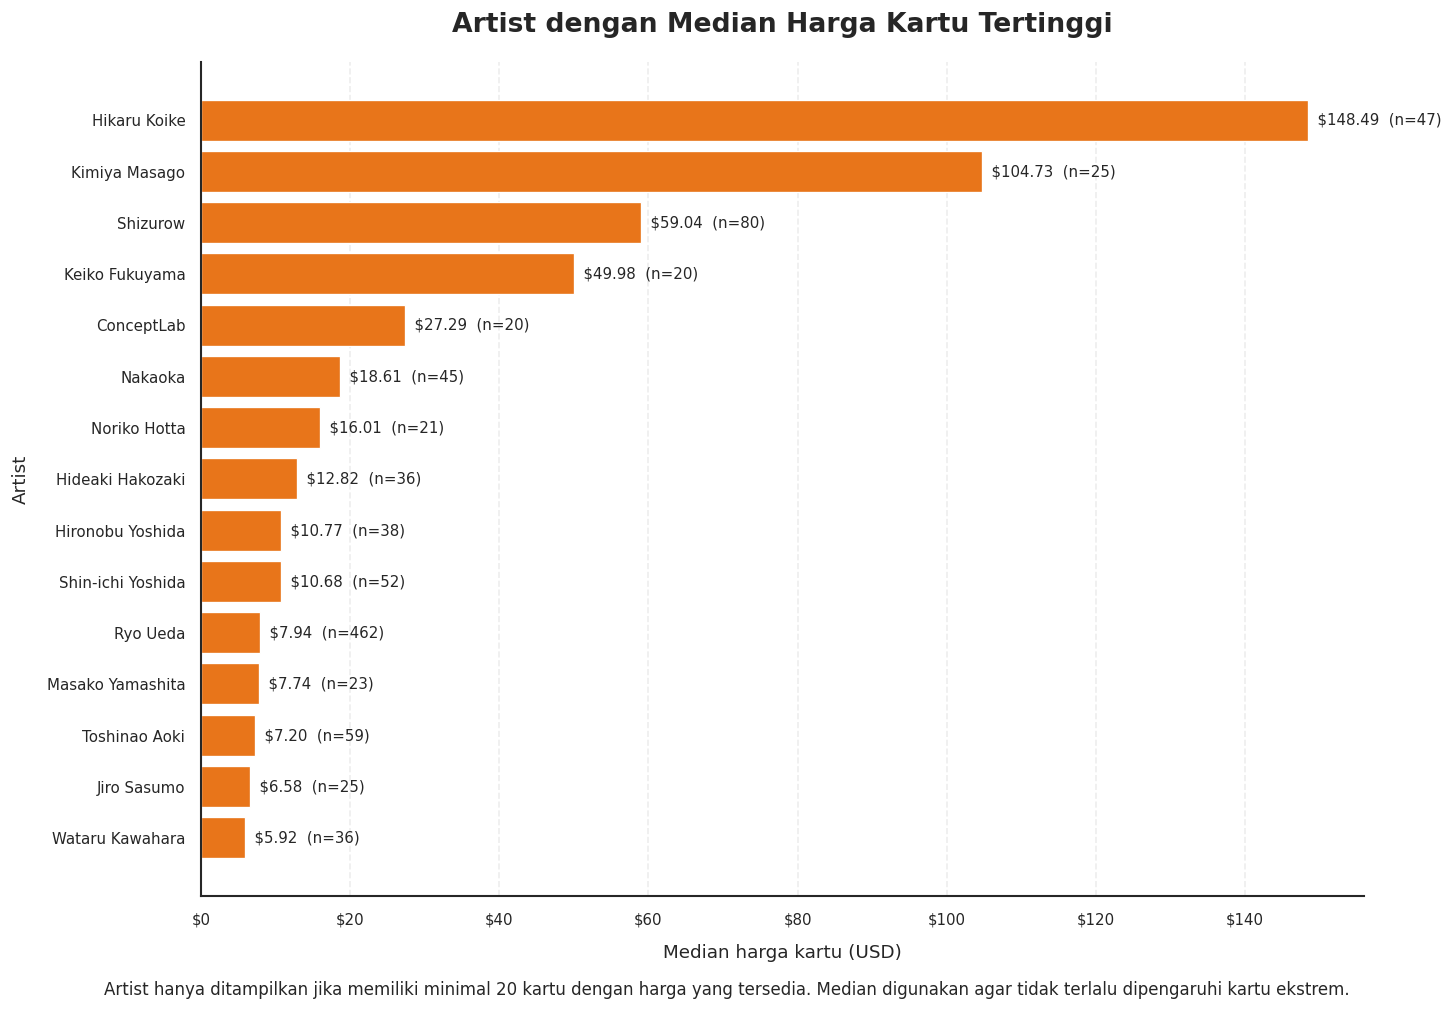

In [35]:
# ============================================================
# 6. HEATMAP TIPE POKEMON x RARITY
# ============================================================

type_df = (
    analysis_df
    .dropna(subset=["types", "rarity"])
    .assign(
        types=lambda data: data["types"].str.split(",")
    )
    .explode("types")
)

type_df["types"] = (
    type_df["types"]
    .astype("string")
    .str.strip()
)

type_summary = (
    type_df
    .groupby(
        ["types", "rarity"],
        observed=False,
    )
    .agg(
        median_price=(
            "effective_market_price",
            "median",
        ),
        card_count=(
            "effective_market_price",
            "count",
        ),
    )
    .reset_index()
)

type_summary.loc[
    type_summary["card_count"] < MIN_SAMPLE_HEATMAP,
    "median_price",
] = np.nan

# Ambil 10 tipe dengan jumlah kartu terbanyak
top_types = (
    type_df["types"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

# Ambil 10 rarity yang paling sering muncul
type_rarities = (
    type_df["rarity"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

type_price_matrix = (
    type_summary
    .pivot(
        index="types",
        columns="rarity",
        values="median_price",
    )
    .reindex(
        index=top_types,
        columns=type_rarities,
    )
)

type_count_matrix = (
    type_summary
    .pivot(
        index="types",
        columns="rarity",
        values="card_count",
    )
    .reindex(
        index=top_types,
        columns=type_rarities,
    )
)

# Hanya pertahankan tipe yang memiliki minimal satu data valid
valid_types = type_price_matrix.notna().any(axis=1)

type_price_matrix = type_price_matrix.loc[valid_types]
type_count_matrix = type_count_matrix.loc[valid_types]

# Bungkus label agar tidak bertabrakan
type_price_matrix.columns = [
    wrap_label(label, width=18)
    for label in type_price_matrix.columns
]

type_count_matrix.columns = type_price_matrix.columns

type_annotation = make_annotation(
    type_price_matrix,
    type_count_matrix,
)

valid_type_prices = type_price_matrix.stack().dropna()

fig, ax = plt.subplots(
    figsize=(
        max(14, len(type_price_matrix.columns) * 1.5),
        max(6, len(type_price_matrix.index) * 0.6),
    ),
    constrained_layout=True,
)

sns.heatmap(
    type_price_matrix,
    ax=ax,
    annot=type_annotation,
    fmt="",
    cmap="YlGnBu",
    linewidths=1.2,
    linecolor="white",
    mask=type_price_matrix.isna(),
    norm=LogNorm(
        vmin=max(valid_type_prices.min(), 0.01),
        vmax=valid_type_prices.max(),
    ),
    cbar_kws={
        "label": "Median harga USD\n(skala warna logaritmik)",
        "shrink": 0.85,
        "pad": 0.03,
    },
    annot_kws={
        "fontsize": 8,
        "fontweight": "bold",
    },
)

ax.set_title(
    "Median Harga berdasarkan Tipe Pokémon dan Kelangkaan",
    pad=20,
)

ax.set_xlabel(
    "Tingkat kelangkaan",
    labelpad=12,
)

ax.set_ylabel(
    "Tipe Pokémon",
    labelpad=12,
)

ax.tick_params(
    axis="x",
    rotation=35,
    pad=8,
)

ax.tick_params(
    axis="y",
    rotation=0,
    pad=8,
)

fig.text(
    0.5,
    -0.015,
    (
        "Satu kartu dapat memiliki lebih dari satu tipe. "
        f"Hanya kombinasi dengan minimal {MIN_SAMPLE_HEATMAP} kartu yang ditampilkan."
    ),
    ha="center",
    va="top",
    fontsize=10,
)

plt.show()


# ============================================================
# 7. GRAFIK ARTIST x HARGA
# ============================================================

MIN_SAMPLE_ARTIST = 20

artist_summary = (
    analysis_df
    .dropna(subset=["artist"])
    .groupby("artist")
    .agg(
        median_price=(
            "effective_market_price",
            "median",
        ),
        card_count=(
            "effective_market_price",
            "count",
        ),
    )
    .query(
        f"card_count >= {MIN_SAMPLE_ARTIST}"
    )
    .sort_values(
        "median_price",
        ascending=True,
    )
    .tail(15)
)

artist_summary.index = [
    wrap_label(label, width=24)
    for label in artist_summary.index
]

fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True,
)

bars = ax.barh(
    artist_summary.index,
    artist_summary["median_price"],
    color="#E8751A",
    edgecolor="white",
    linewidth=0.8,
)

# Label harga di ujung bar
for bar, price, count in zip(
    bars,
    artist_summary["median_price"],
    artist_summary["card_count"],
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  ${price:,.2f}  (n={count:,})",
        va="center",
        ha="left",
        fontsize=9,
    )

ax.set_title(
    "Artist dengan Median Harga Kartu Tertinggi",
    pad=18,
)

ax.set_xlabel(
    "Median harga kartu (USD)",
    labelpad=10,
)

ax.set_ylabel(
    "Artist",
    labelpad=10,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:,.0f}"
    )
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35,
)

ax.grid(
    axis="y",
    visible=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    -0.015,
    (
        "Artist hanya ditampilkan jika memiliki minimal "
        f"{MIN_SAMPLE_ARTIST} kartu dengan harga yang tersedia. "
        "Median digunakan agar tidak terlalu dipengaruhi kartu ekstrem."
    ),
    ha="center",
    va="top",
    fontsize=10,
)

plt.show()

Jumlah kartu valid untuk analisis: 19,686
Median harga seluruh kartu: $0.96


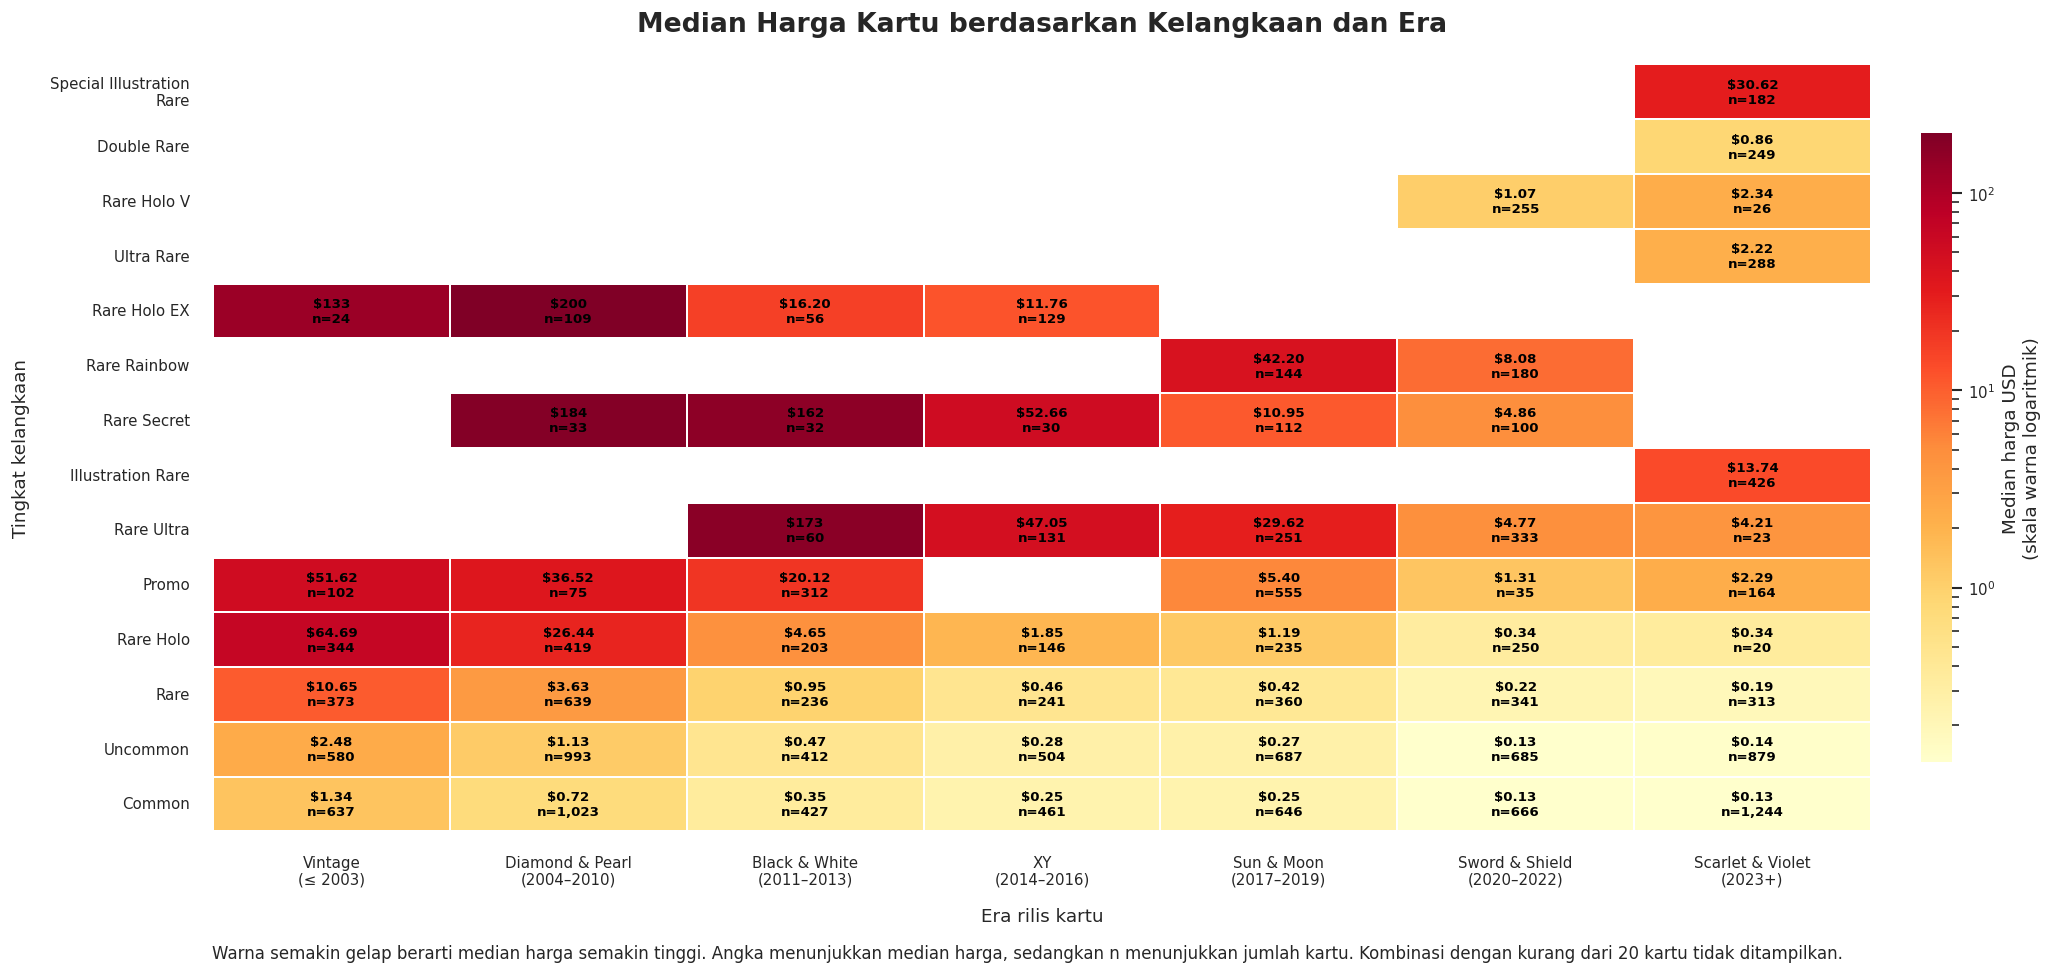

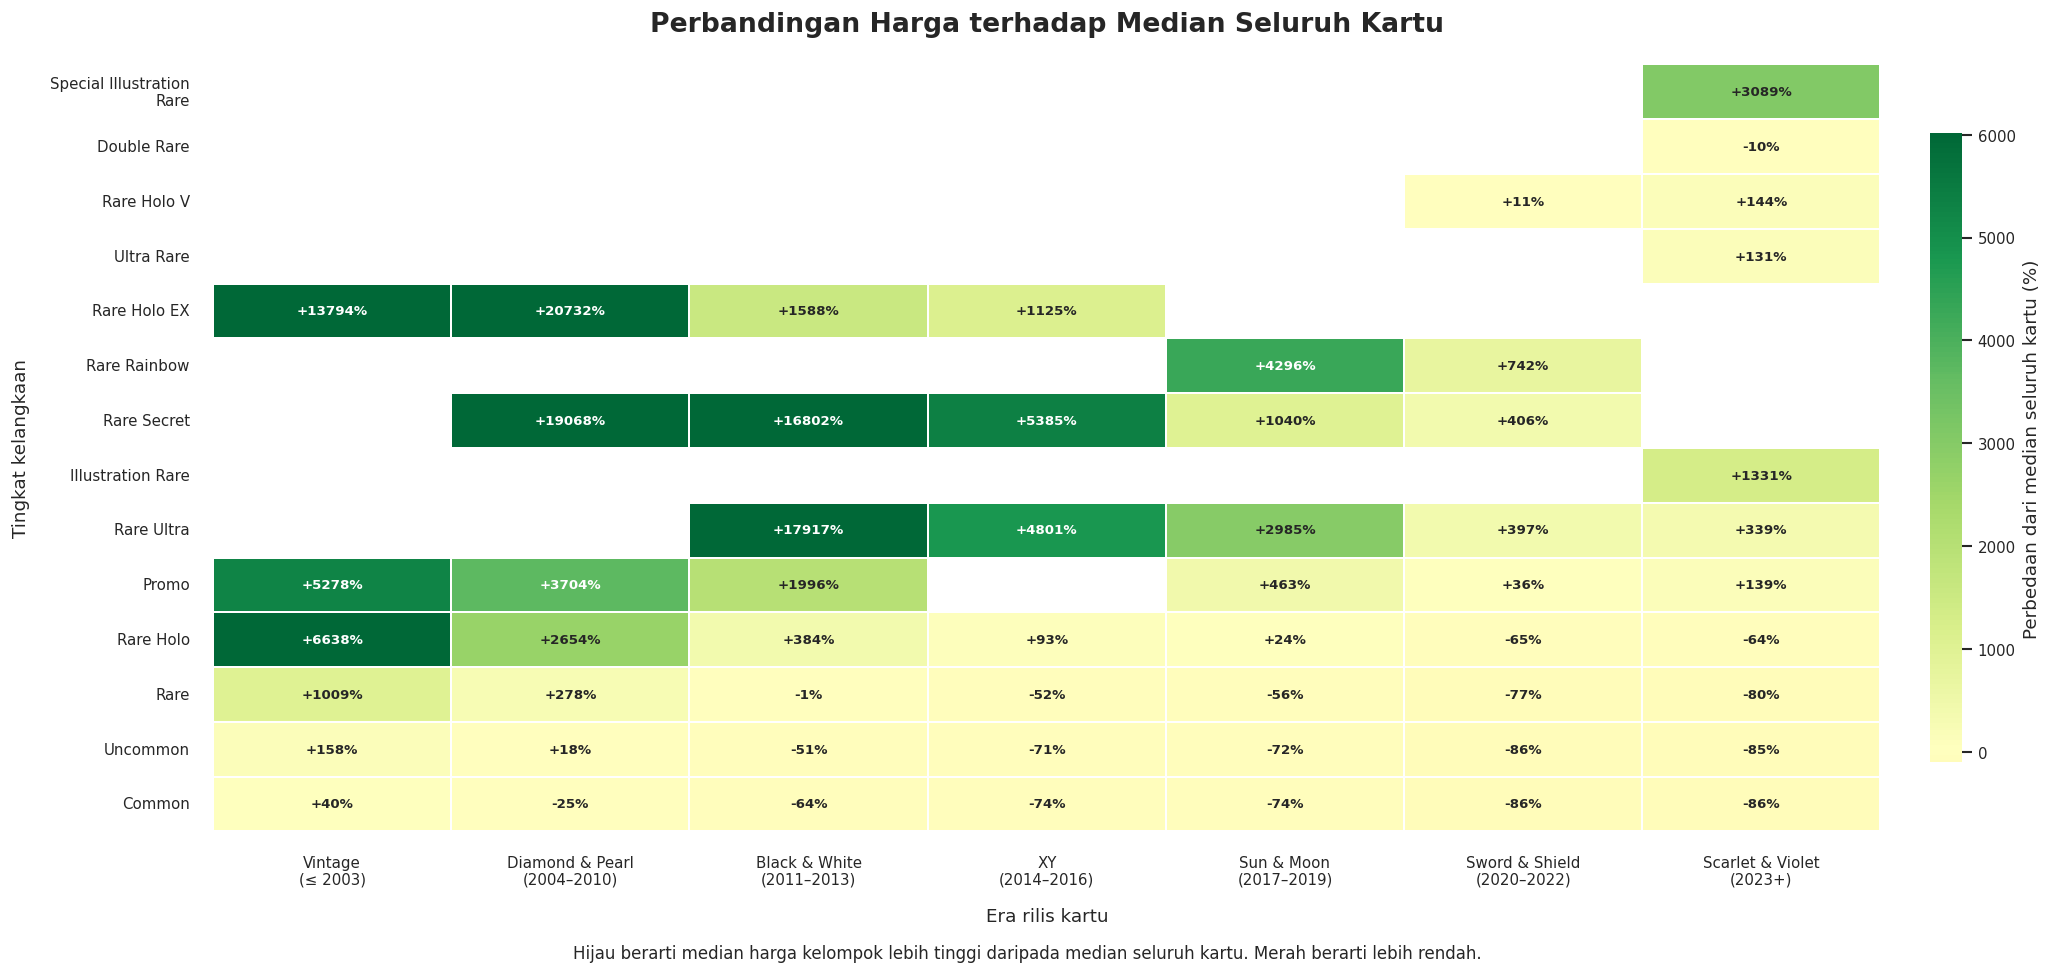

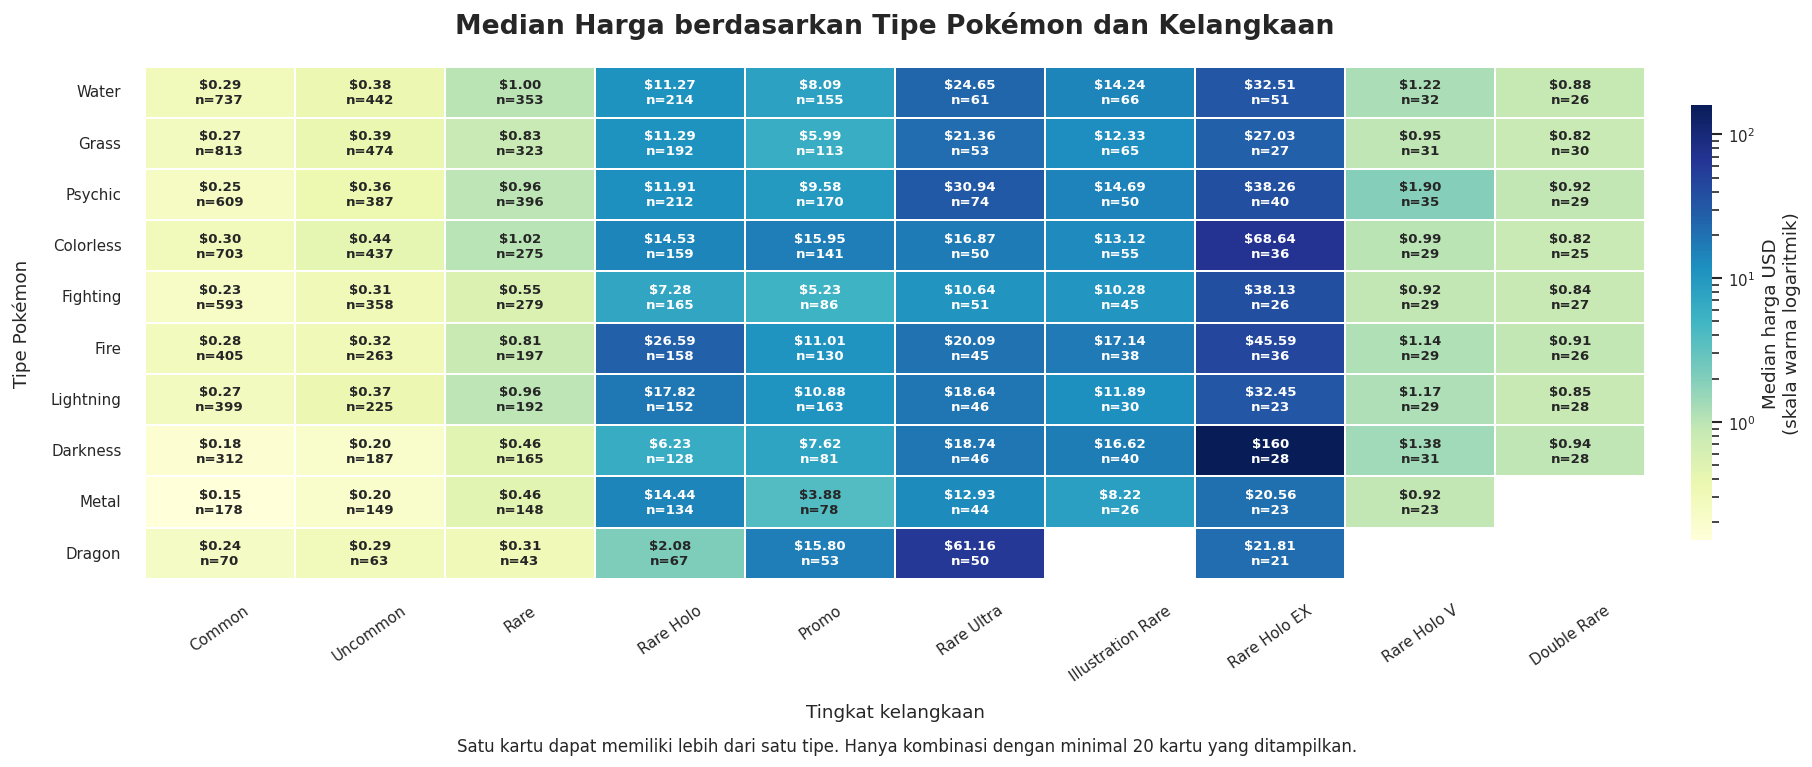

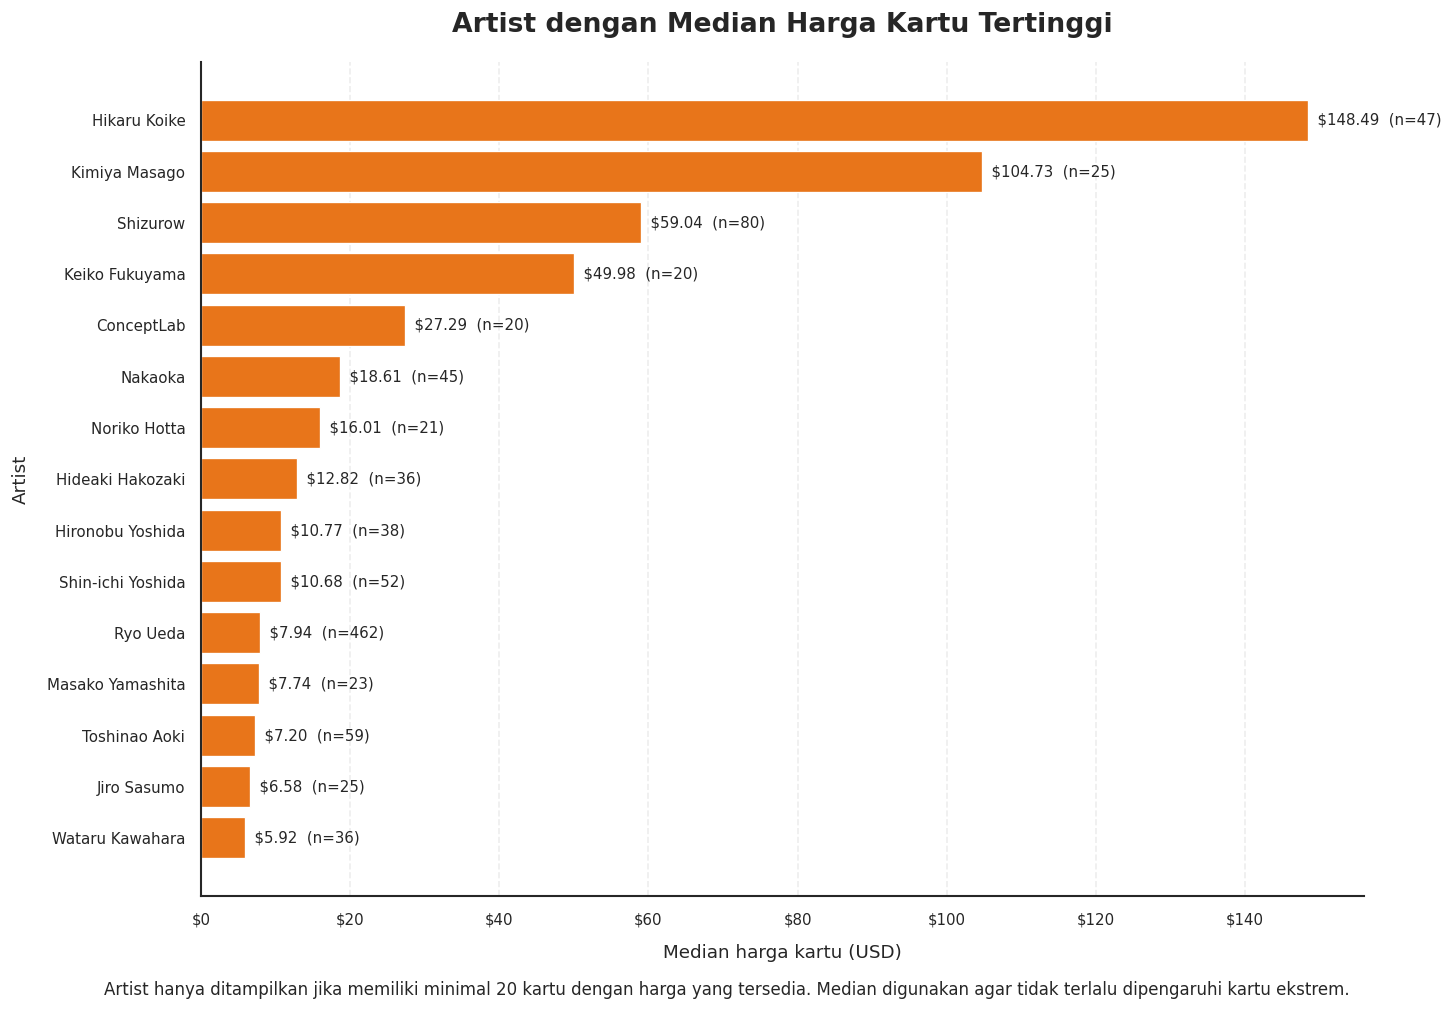

In [33]:
# ============================================================
# VISUALISASI HARGA KARTU POKEMON
# Heatmap Rarity x Era, Type x Rarity, dan Artist x Harga
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------
# Konfigurasi umum visualisasi
# ------------------------------------------------------------

sns.set_theme(
    style="white",
    context="notebook",
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Menghapus chart lama jika cell dijalankan ulang
plt.close("all")


# ============================================================
# 1. PERSIAPAN DATA
# ============================================================

analysis_df = df.copy()

# Konversi tipe data
analysis_df["effective_market_price"] = pd.to_numeric(
    analysis_df["effective_market_price"],
    errors="coerce",
)

analysis_df["release_year"] = pd.to_numeric(
    analysis_df["release_year"],
    errors="coerce",
)

# Ambil hanya data dengan harga valid
analysis_df = analysis_df.dropna(
    subset=[
        "effective_market_price",
        "release_year",
    ]
).copy()

analysis_df = analysis_df[
    analysis_df["effective_market_price"] > 0
].copy()

# Bersihkan teks kategori
text_columns = [
    "rarity",
    "types",
    "artist",
    "supertype",
]

for column in text_columns:
    if column in analysis_df.columns:
        analysis_df[column] = (
            analysis_df[column]
            .astype("string")
            .str.strip()
            .replace({
                "",
                "nan",
                "None",
                "<NA>",
            }, pd.NA)
        )

print(f"Jumlah kartu valid untuk analisis: {len(analysis_df):,}")
print(
    f"Median harga seluruh kartu: "
    f"${analysis_df['effective_market_price'].median():,.2f}"
)


# ============================================================
# 2. FUNGSI BANTU
# ============================================================

def classify_era(year):
    """
    Mengelompokkan tahun rilis menjadi era yang lebih mudah dipahami.
    """
    if year <= 2003:
        return "Vintage\n(≤ 2003)"
    elif year <= 2010:
        return "Diamond & Pearl\n(2004–2010)"
    elif year <= 2013:
        return "Black & White\n(2011–2013)"
    elif year <= 2016:
        return "XY\n(2014–2016)"
    elif year <= 2019:
        return "Sun & Moon\n(2017–2019)"
    elif year <= 2022:
        return "Sword & Shield\n(2020–2022)"
    else:
        return "Scarlet & Violet\n(2023+)"


def wrap_label(text, width=18):
    """
    Membungkus label panjang agar tidak bertabrakan.
    """
    text = str(text)

    if len(text) <= width:
        return text

    words = text.split()
    lines = []
    current_line = ""

    for word in words:
        candidate = f"{current_line} {word}".strip()

        if len(candidate) <= width:
            current_line = candidate
        else:
            if current_line:
                lines.append(current_line)
            current_line = word

    if current_line:
        lines.append(current_line)

    return "\n".join(lines)


def price_label(value):
    """
    Format harga untuk annotation heatmap.
    """
    if pd.isna(value):
        return ""

    if value < 1:
        return f"${value:.2f}"
    elif value < 100:
        return f"${value:,.2f}"
    else:
        return f"${value:,.0f}"


def make_annotation(price_matrix, count_matrix):
    """
    Membuat annotation dengan format:

    $12.50
    n=120
    """
    annotation = price_matrix.copy().astype(object)

    for row in price_matrix.index:
        for column in price_matrix.columns:
            price = price_matrix.loc[row, column]
            count = count_matrix.loc[row, column]

            if pd.isna(price) or pd.isna(count):
                annotation.loc[row, column] = ""
            else:
                annotation.loc[row, column] = (
                    f"{price_label(price)}\n"
                    f"n={int(count):,}"
                )

    return annotation


# ============================================================
# 3. MEMBUAT KOLOM ERA
# ============================================================

era_order = [
    "Vintage\n(≤ 2003)",
    "Diamond & Pearl\n(2004–2010)",
    "Black & White\n(2011–2013)",
    "XY\n(2014–2016)",
    "Sun & Moon\n(2017–2019)",
    "Sword & Shield\n(2020–2022)",
    "Scarlet & Violet\n(2023+)",
]

analysis_df["era"] = analysis_df["release_year"].apply(
    classify_era
)

analysis_df["era"] = pd.Categorical(
    analysis_df["era"],
    categories=era_order,
    ordered=True,
)


# ============================================================
# 4. HEATMAP UTAMA: RARITY x ERA
# ============================================================

# Minimal jumlah kartu dalam satu kombinasi
MIN_SAMPLE_HEATMAP = 20

rarity_era_summary = (
    analysis_df
    .dropna(subset=["rarity", "era"])
    .groupby(
        ["rarity", "era"],
        observed=False,
    )
    .agg(
        median_price=(
            "effective_market_price",
            "median",
        ),
        card_count=(
            "effective_market_price",
            "count",
        ),
    )
    .reset_index()
)

# Kombinasi dengan data terlalu sedikit tidak ditampilkan
rarity_era_summary.loc[
    rarity_era_summary["card_count"] < MIN_SAMPLE_HEATMAP,
    "median_price",
] = np.nan

# Pilih 14 rarity paling banyak memiliki kartu
top_rarities = (
    analysis_df
    .dropna(subset=["rarity"])
    .groupby("rarity")
    .size()
    .sort_values(ascending=False)
    .head(14)
    .index
    .tolist()
)

# Urutan rarity berdasarkan jumlah data
top_rarities = list(reversed(top_rarities))

rarity_era_price = (
    rarity_era_summary
    .pivot(
        index="rarity",
        columns="era",
        values="median_price",
    )
    .reindex(
        index=top_rarities,
        columns=era_order,
    )
)

rarity_era_count = (
    rarity_era_summary
    .pivot(
        index="rarity",
        columns="era",
        values="card_count",
    )
    .reindex(
        index=top_rarities,
        columns=era_order,
    )
)

# Hapus rarity yang tidak memiliki satu pun kombinasi valid
valid_rows = rarity_era_price.notna().any(axis=1)

rarity_era_price = rarity_era_price.loc[valid_rows]
rarity_era_count = rarity_era_count.loc[valid_rows]

# Bungkus label rarity
rarity_era_price.index = [
    wrap_label(label, width=22)
    for label in rarity_era_price.index
]

rarity_era_count.index = rarity_era_price.index

# Annotation harga dan jumlah sampel
rarity_era_annotation = make_annotation(
    rarity_era_price,
    rarity_era_count,
)

# Ambil nilai valid untuk skala warna
valid_prices = rarity_era_price.stack().dropna()

vmin = max(valid_prices.min(), 0.01)
vmax = valid_prices.max()

fig_height = max(
    7,
    len(rarity_era_price.index) * 0.55,
)

fig, ax = plt.subplots(
    figsize=(17, fig_height),
    constrained_layout=True,
)

heatmap = sns.heatmap(
    rarity_era_price,
    ax=ax,
    annot=rarity_era_annotation,
    fmt="",
    cmap="YlOrRd",
    linewidths=1.2,
    linecolor="white",
    mask=rarity_era_price.isna(),
    norm=LogNorm(
        vmin=vmin,
        vmax=vmax,
    ),
    cbar_kws={
        "label": "Median harga USD\n(skala warna logaritmik)",
        "shrink": 0.82,
        "pad": 0.03,
    },
    annot_kws={
        "fontsize": 8,
        "fontweight": "bold",
        "va": "center",
        "ha": "center",
    },
)

ax.set_title(
    "Median Harga Kartu berdasarkan Kelangkaan dan Era",
    pad=20,
)

ax.set_xlabel(
    "Era rilis kartu",
    labelpad=12,
)

ax.set_ylabel(
    "Tingkat kelangkaan",
    labelpad=12,
)

ax.tick_params(
    axis="x",
    rotation=0,
    pad=8,
)

ax.tick_params(
    axis="y",
    rotation=0,
    pad=8,
)

# Warna teks annotation menyesuaikan warna background
for text in ax.texts:
    text.set_color("black")

# Penjelasan sederhana untuk pembaca awam
fig.text(
    0.5,
    -0.015,
    (
        "Warna semakin gelap berarti median harga semakin tinggi. "
        "Angka menunjukkan median harga, sedangkan n menunjukkan jumlah kartu. "
        f"Kombinasi dengan kurang dari {MIN_SAMPLE_HEATMAP} kartu tidak ditampilkan."
    ),
    ha="center",
    va="top",
    fontsize=10,
)

plt.show()


# ============================================================
# 5. HEATMAP PERSENTASE TERHADAP MEDIAN UMUM
# ============================================================

overall_median = analysis_df[
    "effective_market_price"
].median()

relative_price = (
    (rarity_era_price / overall_median) - 1
) * 100

relative_annotation = relative_price.copy().astype(object)

for row in relative_price.index:
    for column in relative_price.columns:
        value = relative_price.loc[row, column]

        if pd.isna(value):
            relative_annotation.loc[row, column] = ""
        else:
            relative_annotation.loc[row, column] = (
                f"{value:+.0f}%"
            )

fig, ax = plt.subplots(
    figsize=(17, fig_height),
    constrained_layout=True,
)

sns.heatmap(
    relative_price,
    ax=ax,
    annot=relative_annotation,
    fmt="",
    cmap="RdYlGn",
    center=0,
    vmin=-100,
    vmax=max(
        100,
        np.nanpercentile(
            np.abs(relative_price.values),
            90,
        ),
    ),
    linewidths=1.2,
    linecolor="white",
    mask=relative_price.isna(),
    cbar_kws={
        "label": "Perbedaan dari median seluruh kartu (%)",
        "shrink": 0.82,
        "pad": 0.03,
    },
    annot_kws={
        "fontsize": 8,
        "fontweight": "bold",
    },
)

ax.set_title(
    "Perbandingan Harga terhadap Median Seluruh Kartu",
    pad=20,
)

ax.set_xlabel(
    "Era rilis kartu",
    labelpad=12,
)

ax.set_ylabel(
    "Tingkat kelangkaan",
    labelpad=12,
)

ax.tick_params(
    axis="x",
    rotation=0,
    pad=8,
)

ax.tick_params(
    axis="y",
    rotation=0,
    pad=8,
)

fig.text(
    0.5,
    -0.015,
    (
        "Hijau berarti median harga kelompok lebih tinggi "
        "daripada median seluruh kartu. Merah berarti lebih rendah."
    ),
    ha="center",
    va="top",
    fontsize=10,
)

plt.show()


# ============================================================
# 6. HEATMAP TIPE POKEMON x RARITY
# ============================================================

type_df = (
    analysis_df
    .dropna(subset=["types", "rarity"])
    .assign(
        types=lambda data: data["types"].str.split(",")
    )
    .explode("types")
)

type_df["types"] = (
    type_df["types"]
    .astype("string")
    .str.strip()
)

type_summary = (
    type_df
    .groupby(
        ["types", "rarity"],
        observed=False,
    )
    .agg(
        median_price=(
            "effective_market_price",
            "median",
        ),
        card_count=(
            "effective_market_price",
            "count",
        ),
    )
    .reset_index()
)

type_summary.loc[
    type_summary["card_count"] < MIN_SAMPLE_HEATMAP,
    "median_price",
] = np.nan

# Ambil 10 tipe dengan jumlah kartu terbanyak
top_types = (
    type_df["types"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

# Ambil 10 rarity yang paling sering muncul
type_rarities = (
    type_df["rarity"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

type_price_matrix = (
    type_summary
    .pivot(
        index="types",
        columns="rarity",
        values="median_price",
    )
    .reindex(
        index=top_types,
        columns=type_rarities,
    )
)

type_count_matrix = (
    type_summary
    .pivot(
        index="types",
        columns="rarity",
        values="card_count",
    )
    .reindex(
        index=top_types,
        columns=type_rarities,
    )
)

# Hanya pertahankan tipe yang memiliki minimal satu data valid
valid_types = type_price_matrix.notna().any(axis=1)

type_price_matrix = type_price_matrix.loc[valid_types]
type_count_matrix = type_count_matrix.loc[valid_types]

# Bungkus label agar tidak bertabrakan
type_price_matrix.columns = [
    wrap_label(label, width=18)
    for label in type_price_matrix.columns
]

type_count_matrix.columns = type_price_matrix.columns

type_annotation = make_annotation(
    type_price_matrix,
    type_count_matrix,
)

valid_type_prices = type_price_matrix.stack().dropna()

fig, ax = plt.subplots(
    figsize=(
        max(14, len(type_price_matrix.columns) * 1.5),
        max(6, len(type_price_matrix.index) * 0.6),
    ),
    constrained_layout=True,
)

sns.heatmap(
    type_price_matrix,
    ax=ax,
    annot=type_annotation,
    fmt="",
    cmap="YlGnBu",
    linewidths=1.2,
    linecolor="white",
    mask=type_price_matrix.isna(),
    norm=LogNorm(
        vmin=max(valid_type_prices.min(), 0.01),
        vmax=valid_type_prices.max(),
    ),
    cbar_kws={
        "label": "Median harga USD\n(skala warna logaritmik)",
        "shrink": 0.85,
        "pad": 0.03,
    },
    annot_kws={
        "fontsize": 8,
        "fontweight": "bold",
    },
)

ax.set_title(
    "Median Harga berdasarkan Tipe Pokémon dan Kelangkaan",
    pad=20,
)

ax.set_xlabel(
    "Tingkat kelangkaan",
    labelpad=12,
)

ax.set_ylabel(
    "Tipe Pokémon",
    labelpad=12,
)

ax.tick_params(
    axis="x",
    rotation=35,
    pad=8,
)

ax.tick_params(
    axis="y",
    rotation=0,
    pad=8,
)

fig.text(
    0.5,
    -0.015,
    (
        "Satu kartu dapat memiliki lebih dari satu tipe. "
        f"Hanya kombinasi dengan minimal {MIN_SAMPLE_HEATMAP} kartu yang ditampilkan."
    ),
    ha="center",
    va="top",
    fontsize=10,
)

plt.show()


# ============================================================
# 7. GRAFIK ARTIST x HARGA
# ============================================================

MIN_SAMPLE_ARTIST = 20

artist_summary = (
    analysis_df
    .dropna(subset=["artist"])
    .groupby("artist")
    .agg(
        median_price=(
            "effective_market_price",
            "median",
        ),
        card_count=(
            "effective_market_price",
            "count",
        ),
    )
    .query(
        f"card_count >= {MIN_SAMPLE_ARTIST}"
    )
    .sort_values(
        "median_price",
        ascending=True,
    )
    .tail(15)
)

artist_summary.index = [
    wrap_label(label, width=24)
    for label in artist_summary.index
]

fig, ax = plt.subplots(
    figsize=(12, 8),
    constrained_layout=True,
)

bars = ax.barh(
    artist_summary.index,
    artist_summary["median_price"],
    color="#E8751A",
    edgecolor="white",
    linewidth=0.8,
)

# Label harga di ujung bar
for bar, price, count in zip(
    bars,
    artist_summary["median_price"],
    artist_summary["card_count"],
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  ${price:,.2f}  (n={count:,})",
        va="center",
        ha="left",
        fontsize=9,
    )

ax.set_title(
    "Artist dengan Median Harga Kartu Tertinggi",
    pad=18,
)

ax.set_xlabel(
    "Median harga kartu (USD)",
    labelpad=10,
)

ax.set_ylabel(
    "Artist",
    labelpad=10,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:,.0f}"
    )
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35,
)

ax.grid(
    axis="y",
    visible=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    -0.015,
    (
        "Artist hanya ditampilkan jika memiliki minimal "
        f"{MIN_SAMPLE_ARTIST} kartu dengan harga yang tersedia. "
        "Median digunakan agar tidak terlalu dipengaruhi kartu ekstrem."
    ),
    ha="center",
    va="top",
    fontsize=10,
)

plt.show()